### Deep Agents overview\n","\n","\n","\n","Build agents that can plan, use subagents, and leverage file systems for complex tasks\n","\n","deepagents is a standalone library for building agents that can tackle complex, multi-step tasks. Built on LangGraph and inspired by applications like Claude Code, Deep Research, and Manus, deep agents come with planning capabilities, file systems for context management, and the ability to spawn subagents.

In [1]:
# Basic deep agent

import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY") 
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")



In [2]:
from tavily import TavilyClient
from typing import Literal

tavily_client = TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))
# Use tavily client in a tool. Internet search tool

def web_search(query:str,
max_results:int=5,
topic:Literal["sports","news","finance"]="general",
include_raw_content:bool=False):
    """Run a web search"""
    return tavily_client.search(query,max_results=max_results,include_raw_content=include_raw_content,topic=topic,)



In [14]:
from langchain_groq import ChatGroq

model = ChatGroq(model="llama-3.1-8b-instant")
model

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.10'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x11e35fd10>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x11e832e70>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [10]:
from langchain.chat_models import init_chat_model

model_init = init_chat_model("groq:qwen/qwen3-32b")
model_init

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.10'}}, output_version=None, profile={'name': 'Qwen3 32B', 'release_date': '2024-12-23', 'last_updated': '2024-12-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 40960, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x11b0f2ab0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x11e3542c0>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [17]:
from langchain_openai import ChatOpenAI
model_openai = ChatOpenAI(model="gpt-4o-mini")


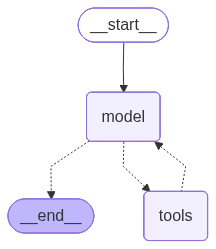

In [8]:
## Basic Agent
from langchain.agents import create_agent

create_agnt = create_agent(model=model,tools=[web_search])

create_agnt

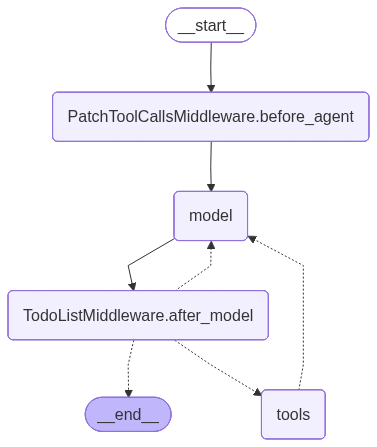

In [18]:
## Create a deep agent
## Prompt

## Agent
from deepagents import create_deep_agent

deep_agent = create_deep_agent(tools=[web_search],system_prompt="Act as a researcher",model=model_openai)

deep_agent

In [19]:
result= deep_agent.invoke({"messages":{"role":"user","content":"What is langgraph?"}})
result

{'messages': [HumanMessage(content='What is langgraph?', additional_kwargs={}, response_metadata={}, id='de848eff-055d-4ddf-8ae7-e5fd6f3ff391'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 5380, 'total_tokens': 5400, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_f5cf055e49', 'id': 'chatcmpl-DsW34Z5jdWwrKPBStxd5ivsMlBnnH', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ee0a3-93e7-76f3-a2aa-e7db2977b29d-0', tool_calls=[{'name': 'web_search', 'args': {'query': 'langgraph', 'max_results': 5}, 'id': 'call_mVdEEcpR0XNvCXN1d3QxoaWN', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_token

In [20]:
result["messages"][-1].content

'LangGraph is an open-source framework developed by LangChain, designed to build and manage AI agent workflows using graph-based structures. It allows developers to represent workflows through nodes and edges, offering a more structured and scalable way to handle complex interactions between agents compared to traditional linear frameworks.\n\nKey features of LangGraph include:\n- **Flexible Workflows**: Unlike fixed-step pipelines, LangGraph can handle branching and parallel steps, making it suitable for decision-based applications.\n- **Durable Execution**: It supports long-running, stateful agents, ensuring persistence and reliability in execution.\n- **Integration with AgentFrameworks**: LangGraph serves as the infrastructure for developing various AI applications, including chatbots and agent-based systems.\n\nFor more detailed information, you can explore resources from [IBM](https://www.ibm.com/think/topics/langgraph) and [GeeksforGeeks](https://www.geeksforgeeks.org/machine-lea

In [21]:
result['files']

{}